In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [5]:
df = pd.read_csv(r"C:\Users\samca\OneDrive\Documents\anaconda_projects\all_seasons.csv")
df.head()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [6]:
df.shape

(12844, 22)

In [7]:
df.columns.tolist()

['Unnamed: 0',
 'player_name',
 'team_abbreviation',
 'age',
 'player_height',
 'player_weight',
 'college',
 'country',
 'draft_year',
 'draft_round',
 'draft_number',
 'gp',
 'pts',
 'reb',
 'ast',
 'net_rating',
 'oreb_pct',
 'dreb_pct',
 'usg_pct',
 'ts_pct',
 'ast_pct',
 'season']

In [8]:
df.isnull().sum()

Unnamed: 0              0
player_name             0
team_abbreviation       0
age                     0
player_height           0
player_weight           0
college              1854
country                 0
draft_year              0
draft_round             0
draft_number            0
gp                      0
pts                     0
reb                     0
ast                     0
net_rating              0
oreb_pct                0
dreb_pct                0
usg_pct                 0
ts_pct                  0
ast_pct                 0
season                  0
dtype: int64

In [9]:
df.describe()

,Unnamed: 0,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000
mean,6421.500000,27.045313,200.555097,100.263279,51.154158,8.212582,3.558486,1.824681,-2.226339,0.054073,0.140646,0.184641,0.513138,0.131595
std,3707.887763,4.339211,9.111090,12.426628,25.084904,6.016573,2.477885,1.800840,12.665124,0.043335,0.062513,0.053545,0.101724,0.094172
min,0.000000,18.000000,160.020000,60.327736,1.000000,0.000000,0.000000,0.000000,-250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3210.750000,24.000000,193.040000,90.718400,31.000000,3.600000,1.800000,0.600000,-6.400000,0.021000,0.096000,0.149000,0.482000,0.066000
50%,6421.500000,26.000000,200.660000,99.790240,57.000000,6.700000,3.000000,1.200000,-1.300000,0.040000,0.130500,0.181000,0.525000,0.103000
75%,9632.250000,30.000000,208.280000,108.862080,73.000000,11.500000,4.700000,2.400000,3.200000,0.083000,0.179000,0.217000,0.563000,0.179000
max,12843.000000,44.000000,231.140000,163.293120,85.000000,36.100000,16.300000,11.700000,300.000000,1.000000,1.000000,1.000000,1.500000,1.000000


In [10]:
career_df = df.groupby('player_name').agg(
    seasons_played=('season', 'nunique'),
    avg_pts=('pts', 'mean'),
    avg_reb=('reb', 'mean'),
    avg_ast=('ast', 'mean'),
    avg_usg=('usg_pct', 'mean'),
    avg_ts=('ts_pct', 'mean'),
    avg_ast_pct=('ast_pct', 'mean'),
    avg_oreb=('oreb_pct', 'mean'),
    avg_dreb=('dreb_pct', 'mean'),
    avg_net=('net_rating', 'mean')
).reset_index()

print(career_df.shape)
career_df.head()

(2551, 11)


,player_name,seasons_played,avg_pts,avg_reb,avg_ast,avg_usg,avg_ts,avg_ast_pct,avg_oreb,avg_dreb,avg_net
0,A.C. Green,5,5.78,6.06,0.860000,0.1274,0.4868,0.054,0.093000,0.1864,-1.88
1,A.J. Bramlett,1,1.00,2.80,0.000000,0.1460,0.1900,0.000,0.158000,0.2080,-32.60
2,A.J. Guyton,3,3.80,0.70,1.566667,0.2240,0.3240,0.282,0.013333,0.0400,-6.70
3,A.J. Lawson,1,3.70,1.40,0.100000,0.1890,0.5890,0.032,0.046000,0.1520,-20.10
4,AJ Green,1,4.40,1.30,0.600000,0.1590,0.6070,0.092,0.016000,0.1050,-4.90


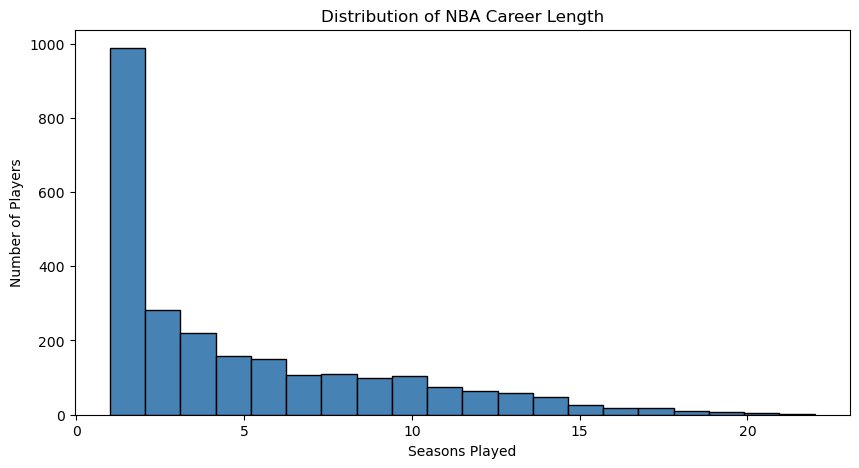

count    2551.000000
mean        5.033320
std         4.223379
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max        22.000000
Name: seasons_played, dtype: float64


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(career_df['seasons_played'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of NBA Career Length')
plt.xlabel('Seasons Played')
plt.ylabel('Number of Players')
plt.show()

print(career_df['seasons_played'].describe())

In [12]:
features = ['avg_pts', 'avg_reb', 'avg_ast', 'avg_usg', 
            'avg_ts', 'avg_ast_pct', 'avg_oreb', 'avg_dreb', 'avg_net']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(career_df[features])

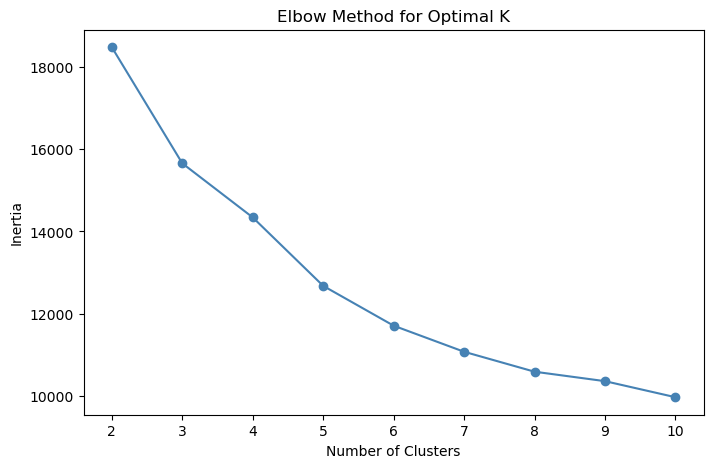

In [13]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42)
career_df['cluster'] = kmeans.fit_predict(X_scaled)

career_df.groupby('cluster')[features].mean().round(3)

,avg_pts,avg_reb,avg_ast,avg_usg,avg_ts,avg_ast_pct,avg_oreb,avg_dreb,avg_net
cluster,,,,,,,,,
0,3.425,2.594,0.455,0.159,0.493,0.061,0.091,0.174,-3.353
1,0.827,0.711,0.240,0.159,0.167,0.072,0.036,0.094,-41.123
2,10.897,6.071,1.559,0.195,0.547,0.096,0.078,0.187,-1.081
3,13.039,3.440,4.289,0.220,0.532,0.252,0.025,0.107,-0.157
4,4.779,1.621,1.222,0.178,0.485,0.145,0.028,0.096,-3.687


In [15]:
cluster_names = {
    0: 'Backup Bigs',
    1: 'Fringe Players',
    2: 'Primary Bigs',
    3: 'Playmakers',
    4: 'Wing Role Players'
}

career_df['archetype'] = career_df['cluster'].map(cluster_names)
career_df['archetype'].value_counts()

archetype
Wing Role Players    1011
Backup Bigs           768
Primary Bigs          362
Playmakers            278
Fringe Players        132
Name: count, dtype: int64

archetype
Playmakers           9.03
Primary Bigs         8.79
Backup Bigs          3.96
Wing Role Players    3.88
Fringe Players       1.35
Name: seasons_played, dtype: float64


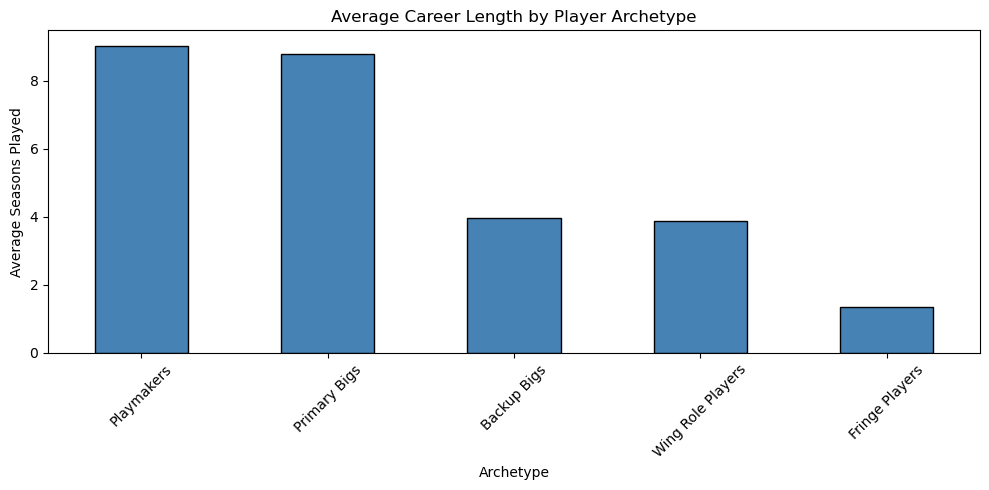

In [16]:
longevity = career_df.groupby('archetype')['seasons_played'].mean().sort_values(ascending=False).round(2)
print(longevity)

plt.figure(figsize=(10,5))
longevity.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Career Length by Player Archetype')
plt.xlabel('Archetype')
plt.ylabel('Average Seasons Played')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

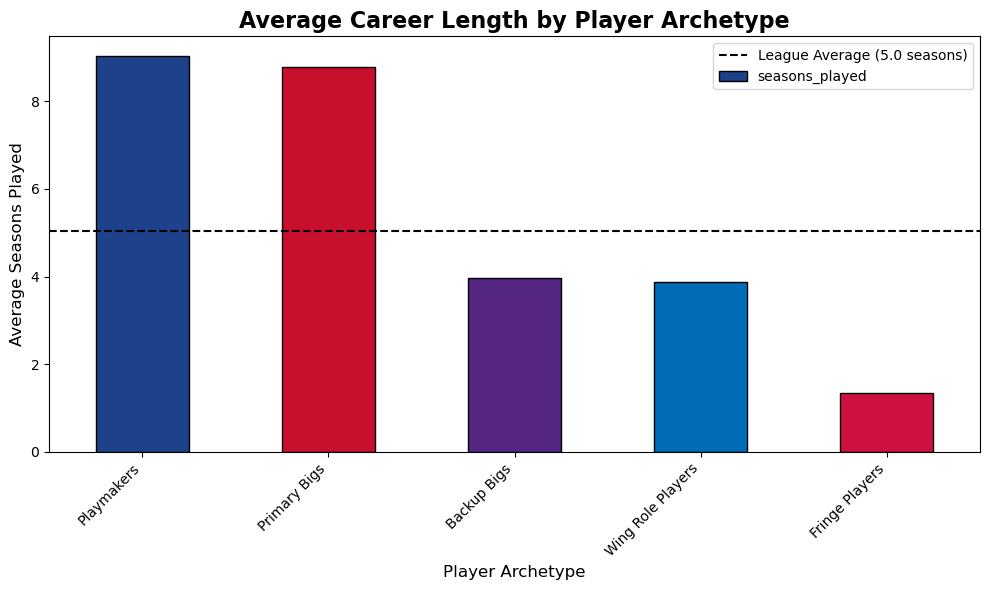

In [17]:
colors = ['#1d428a', '#c8102e', '#552583', '#006bb6', '#ce1141']

plt.figure(figsize=(10,6))
longevity.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Average Career Length by Player Archetype', fontsize=16, fontweight='bold')
plt.xlabel('Player Archetype', fontsize=12)
plt.ylabel('Average Seasons Played', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=career_df['seasons_played'].mean(), color='black', linestyle='--', label=f'League Average ({career_df["seasons_played"].mean():.1f} seasons)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
from sklearn.linear_model import LinearRegression
import pandas as pd

archetype_dummies = pd.get_dummies(career_df['archetype'], drop_first=True)
X = archetype_dummies
y = career_df['seasons_played']

model = LinearRegression()
model.fit(X, y)

results = pd.DataFrame({
    'Archetype': X.columns,
    'Coefficient': model.coef_.round(2)
})
print(f"Baseline (Backup Bigs) intercept: {model.intercept_.round(2)}")
print(results)

Baseline (Backup Bigs) intercept: 3.96
           Archetype  Coefficient
0     Fringe Players        -2.62
1         Playmakers         5.06
2       Primary Bigs         4.83
3  Wing Role Players        -0.08


In [19]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R-squared: {r2:.3f}")

R-squared: 0.298


<Figure size 1200x600 with 0 Axes>

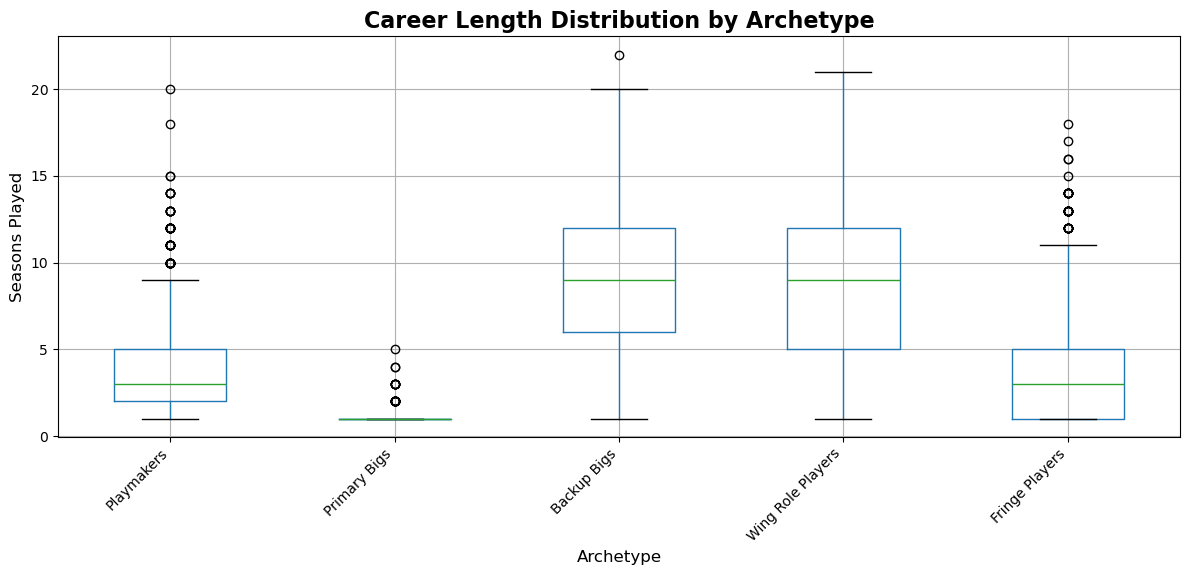

In [20]:
plt.figure(figsize=(12,6))
order = ['Playmakers', 'Primary Bigs', 'Backup Bigs', 'Wing Role Players', 'Fringe Players']
career_df.boxplot(column='seasons_played', by='archetype', 
                  positions=range(len(order)),
                  figsize=(12,6))
plt.suptitle('')
plt.title('Career Length Distribution by Archetype', fontsize=16, fontweight='bold')
plt.xlabel('Archetype', fontsize=12)
plt.ylabel('Seasons Played', fontsize=12)
plt.xticks(range(len(order)), order, rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
print(career_df[career_df['archetype'] == 'Primary Bigs']['seasons_played'].describe())
print()
print(career_df[career_df['archetype'] == 'Primary Bigs'].nlargest(10, 'seasons_played')[['player_name', 'seasons_played', 'avg_pts', 'avg_reb']])

count    362.000000
mean       8.790055
std        4.470911
min        1.000000
25%        5.000000
50%        9.000000
75%       12.000000
max       21.000000
Name: seasons_played, dtype: float64

          player_name  seasons_played    avg_pts    avg_reb
677     Dirk Nowitzki              21  20.109524   7.347619
1436    Kevin Garnett              20  17.350000   9.830000
330   Carmelo Anthony              19  22.015789   6.163158
2314       Tim Duncan              19  18.889474  10.768421
2431   Tyson Chandler              19   7.821053   8.721053
729     Dwight Howard              18  15.388889  11.527778
1193  Jermaine O'Neal              18  12.150000   6.688889
1925        Pau Gasol              18  16.561111   9.044444
2381     Trevor Ariza              18   9.844444   4.677778
772       Elton Brand              17  14.841176   8.111765


C:\Users\samca\AppData\Local\Temp\ipykernel_27056\1510750050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=career_df, x='archetype', y='seasons_played',


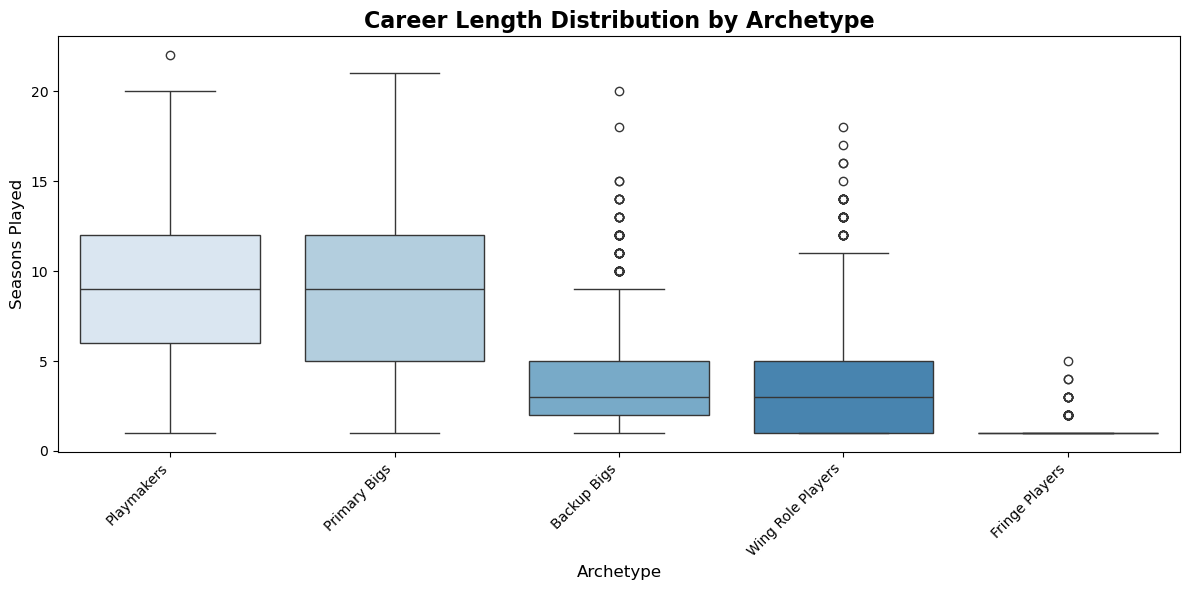

In [22]:
import seaborn as sns

plt.figure(figsize=(12,6))
order = ['Playmakers', 'Primary Bigs', 'Backup Bigs', 'Wing Role Players', 'Fringe Players']

sns.boxplot(data=career_df, x='archetype', y='seasons_played', 
            order=order, palette='Blues')

plt.title('Career Length Distribution by Archetype', fontsize=16, fontweight='bold')
plt.xlabel('Archetype', fontsize=12)
plt.ylabel('Seasons Played', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

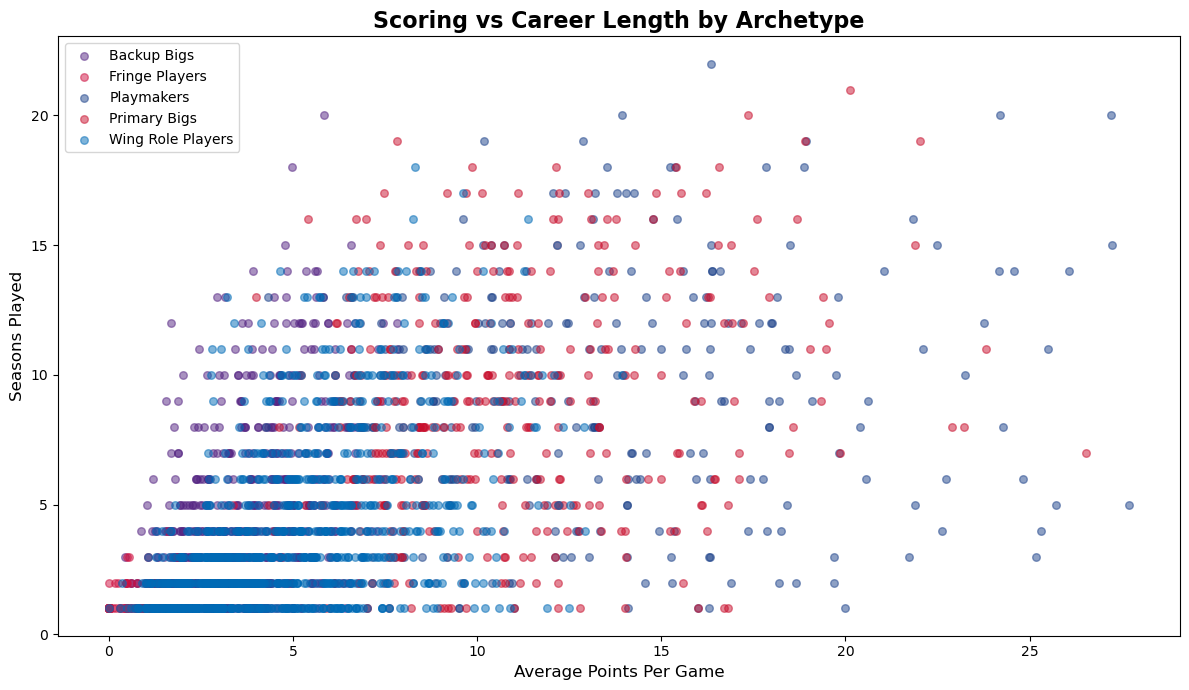

In [23]:
plt.figure(figsize=(12,7))
colors = {
    'Playmakers': '#1d428a',
    'Primary Bigs': '#c8102e', 
    'Backup Bigs': '#552583',
    'Wing Role Players': '#006bb6',
    'Fringe Players': '#ce1141'
}

for archetype, group in career_df.groupby('archetype'):
    plt.scatter(group['avg_pts'], group['seasons_played'], 
                label=archetype, alpha=0.5, 
                color=colors[archetype], s=30)

plt.title('Scoring vs Career Length by Archetype', fontsize=16, fontweight='bold')
plt.xlabel('Average Points Per Game', fontsize=12)
plt.ylabel('Seasons Played', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()